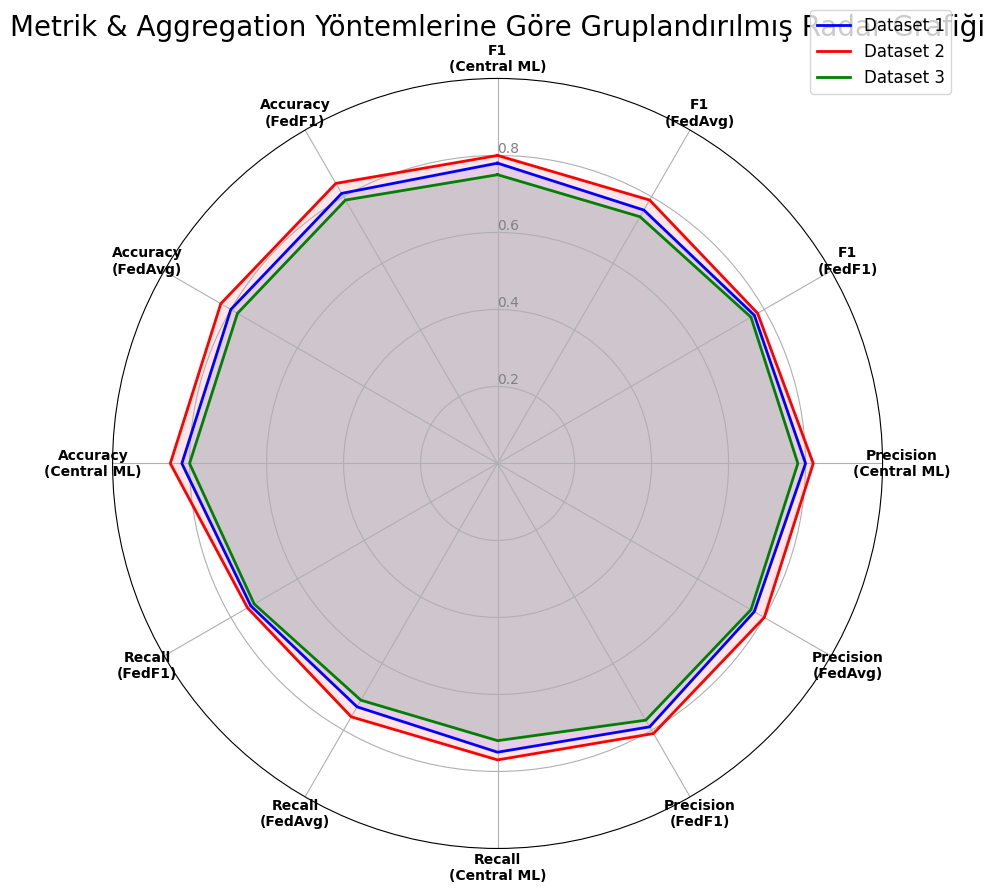

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Aggregation yöntemleri
agg_methods = ["Central ML", "FedAvg", "FedF1"]
# Datasetlerdeki metrikler orijinal sırası
original_metrics = ["Precision", "Recall", "F1", "Accuracy"]
# Radar grafikte istenen metrik sıralaması (örneğin F1'lar en önde)
desired_metrics_order = ["F1", "Precision", "Recall", "Accuracy"]

# X ekseninde etiketleri istenen sıraya göre oluşturuyoruz
labels = [f"{metric}\n({agg})" for metric in desired_metrics_order for agg in agg_methods]

# Örnek dataset değerleri (deneysel sonuçlarınıza göre düzenleyebilirsiniz)
dataset_values = {
    "Dataset 1": {
        "Central ML": [0.80, 0.75, 0.78, 0.82],
        "FedAvg": [0.77, 0.73, 0.76, 0.80],
        "FedF1": [0.79, 0.74, 0.77, 0.81]
    },
    "Dataset 2": {
        "Central ML": [0.82, 0.77, 0.80, 0.85],
        "FedAvg": [0.80, 0.76, 0.79, 0.83],
        "FedF1": [0.81, 0.75, 0.78, 0.84]
    },
    "Dataset 3": {
        "Central ML": [0.78, 0.72, 0.75, 0.80],
        "FedAvg": [0.76, 0.71, 0.74, 0.78],
        "FedF1": [0.77, 0.73, 0.76, 0.79]
    }
}

# Datasetlerdeki değerleri, istenen metrik sırasına göre yeniden düzenleyelim
data_values = {}
for dataset, methods in dataset_values.items():
    values = []
    for metric in desired_metrics_order:
        # Orijinal dizideki index'i buluyoruz
        idx = original_metrics.index(metric)
        for agg in agg_methods:
            values.append(methods[agg][idx])
    data_values[dataset] = values

# Toplam spoke sayısı: istenen etiket sayısı (grup başına 3, toplam 4 grup => 12 spoke)
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # Döngüyü tamamlamak için ilk açıyı ekliyoruz

# Her datasetin değer dizisine de ilk değeri ekleyerek döngüyü kapatalım
for dataset in data_values:
    data_values[dataset] = data_values[dataset] + data_values[dataset][:1]

# Radar grafiğin çizimi
plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], labels, fontsize=10, fontweight='bold')

ax.set_rscale("linear")
ax.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8], ["0.2", "0.4", "0.6", "0.8"], color="grey", size=10)
plt.ylim(0, 1)

# Dataset renkleri
dataset_colors = {"Dataset 1": "blue", "Dataset 2": "red", "Dataset 3": "green"}

# Her dataset için çizgileri çizelim
for dataset, values in data_values.items():
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=dataset, color=dataset_colors[dataset])
    ax.fill(angles, values, color=dataset_colors[dataset], alpha=0.1)

plt.title("Metrik & Aggregation Yöntemlerine Göre Gruplandırılmış Radar Grafiği", 
          size=20, position=(0.5, 1.1), ha='center')
plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1), fontsize=12)
plt.show()


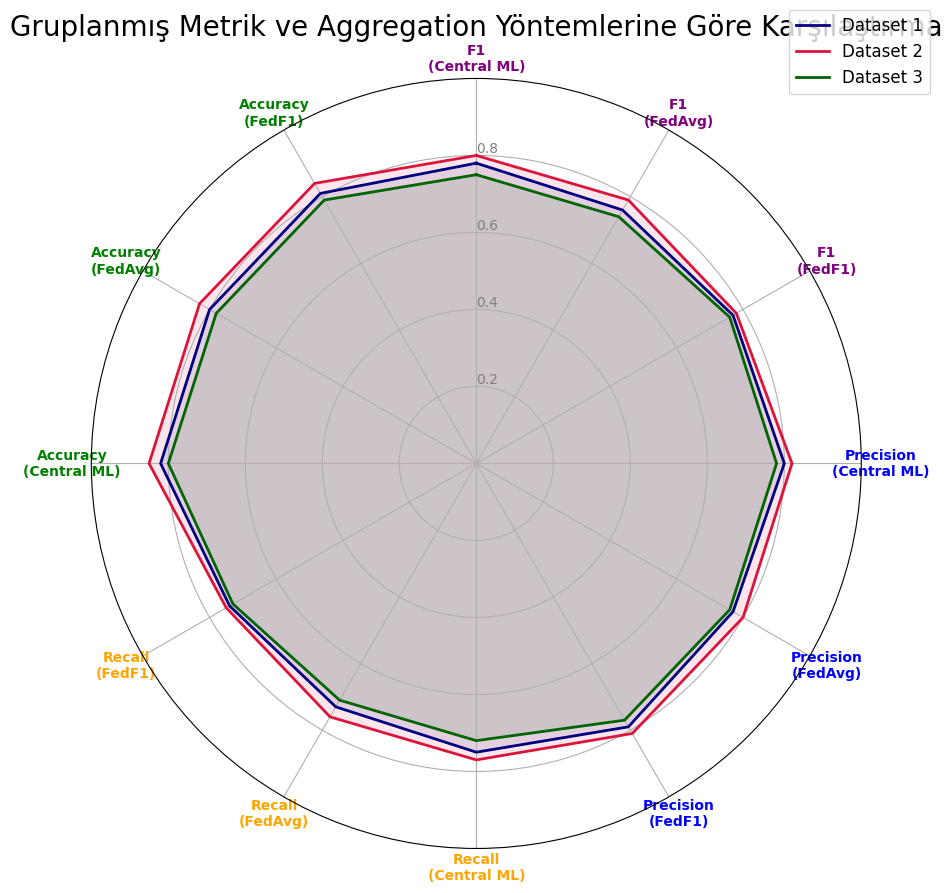

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Aggregation yöntemleri ve metrik isimleri
agg_methods = ["Central ML", "FedAvg", "FedF1"]
original_metrics = ["Precision", "Recall", "F1", "Accuracy"]
# İstenilen metrik sırası: Örneğin önce F1, sonra Precision, Recall ve Accuracy
desired_metrics_order = ["F1", "Precision", "Recall", "Accuracy"]

# Her metrik için renk tanımlaması
metric_colors = {
    "F1": "purple",
    "Precision": "blue",
    "Recall": "orange",
    "Accuracy": "green"
}

# X ekseni etiketleri: önce F1 için üç aggregation yöntemi, sonra Precision vs.
labels = [f"{metric}\n({agg})" for metric in desired_metrics_order for agg in agg_methods]

# Örnek dataset değerleri (deneysel sonuçlarınıza göre düzenleyebilirsiniz)
dataset_values = {
    "Dataset 1": {
        "Central ML": [0.80, 0.75, 0.78, 0.82],
        "FedAvg": [0.77, 0.73, 0.76, 0.80],
        "FedF1": [0.79, 0.74, 0.77, 0.81]
    },
    "Dataset 2": {
        "Central ML": [0.82, 0.77, 0.80, 0.85],
        "FedAvg": [0.80, 0.76, 0.79, 0.83],
        "FedF1": [0.81, 0.75, 0.78, 0.84]
    },
    "Dataset 3": {
        "Central ML": [0.78, 0.72, 0.75, 0.80],
        "FedAvg": [0.76, 0.71, 0.74, 0.78],
        "FedF1": [0.77, 0.73, 0.76, 0.79]
    }
}

# Dataset değerlerini istenen metrik sırasına göre yeniden düzenleyelim
data_values = {}
for dataset, methods in dataset_values.items():
    values = []
    for metric in desired_metrics_order:
        # Orijinal dizideki index'i buluyoruz
        idx = original_metrics.index(metric)
        for agg in agg_methods:
            values.append(methods[agg][idx])
    data_values[dataset] = values

# Toplam spoke sayısı (4 metrik * 3 aggregation = 12)
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # Döngüyü tamamlamak için

# Her dataset için değer dizisini döngüyü kapatacak şekilde güncelleyelim
for dataset in data_values:
    data_values[dataset] = data_values[dataset] + data_values[dataset][:1]

# Grafik ayarları
plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# X ekseni etiketlerini yerleştir
plt.xticks(angles[:-1], labels, fontsize=10, fontweight='bold')
# X tick label'larını metrik bazında renklendirme
tick_labels = ax.get_xticklabels()
for tick in tick_labels:
    # Etiketteki ilk satır metrik adını alıyoruz
    metric = tick.get_text().split('\n')[0]
    tick.set_color(metric_colors.get(metric, "black"))

ax.set_rscale("linear")
ax.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8], ["0.2", "0.4", "0.6", "0.8"], color="grey", size=10)
plt.ylim(0, 1)

# Dataset renkleri
dataset_colors = {"Dataset 1": "navy", "Dataset 2": "crimson", "Dataset 3": "darkgreen"}

# Her dataset için çizgileri çizelim
for dataset, values in data_values.items():
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=dataset, color=dataset_colors[dataset])
    ax.fill(angles, values, color=dataset_colors[dataset], alpha=0.1)

plt.title("Gruplanmış Metrik ve Aggregation Yöntemlerine Göre Karşılaştırma", 
          size=20, position=(0.5, 1.1), ha='center')
plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1), fontsize=12)
plt.show()
